In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

print("✓ Imports complete")

✓ Imports complete


In [3]:
df_train = pd.read_parquet("../data/processed/splits/train.parquet")

print(f"✓ Training split loaded")
print(f"  Shape : {df_train.shape}")
print(f"  Rows  : {len(df_train):,}")
print(f"\n  Reminder: EDA is performed ONLY on training data.")
print(f"  Val and Test sets are untouched until evaluation.")

✓ Training split loaded
  Shape : (67526, 40)
  Rows  : 67,526

  Reminder: EDA is performed ONLY on training data.
  Val and Test sets are untouched until evaluation.


In [4]:
ts_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in ts_cols:
    if col in df_train.columns:
        df_train[col] = pd.to_datetime(df_train[col], errors="coerce")

print("✓ Timestamp columns restored")
print(df_train[ts_cols].dtypes.to_string())

✓ Timestamp columns restored
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]


In [5]:
null_counts = df_train.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

print("MISSING VALUES IN TRAINING SET\n")
print(f"  {'Column':<45} {'Nulls':>8}  {'%':>7}")
print("  " + "-" * 65)
for col, cnt in null_counts.items():
    pct = cnt / len(df_train) * 100
    bar = "█" * int(pct / 2)
    print(f"  {col:<45} {cnt:>8}  {pct:>6.2f}%  {bar}")

print(f"\n  Total columns with nulls : {len(null_counts)}")
print(f"  Total columns            : {df_train.shape[1]}")

MISSING VALUES IN TRAINING SET

  Column                                           Nulls        %
  -----------------------------------------------------------------
  product_category_name_english                      941    1.39%  
  product_category_name                              927    1.37%  
  product_name_lenght                                927    1.37%  
  product_description_lenght                         927    1.37%  
  product_photos_qty                                 927    1.37%  
  has_review_comment                                 451    0.67%  
  review_count                                       451    0.67%  
  review_score                                       451    0.67%  
  product_width_cm                                    12    0.02%  
  product_height_cm                                   12    0.02%  
  product_length_cm                                   12    0.02%  
  product_weight_g                                    12    0.02%  
  order_approved_a

In [6]:
target = df_train["lead_time_variance"]

print("TARGET VARIABLE — DEEP DIVE (train set)\n")
print(f"  Mean     : {target.mean():.4f} days")
print(f"  Median   : {target.median():.4f} days")
print(f"  Std Dev  : {target.std():.4f} days")
print(f"  Skewness : {target.skew():.4f}")
print(f"  Kurtosis : {target.kurtosis():.4f}")
print(f"\n  Percentile breakdown:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"    {p:>3}th pct : {target.quantile(p/100):>9.3f} days")

print(f"\n  Orders late  (> 0 days)  : {(target > 0).sum():,}  ({(target > 0).mean()*100:.2f}%)")
print(f"  Orders early (< 0 days)  : {(target < 0).sum():,}  ({(target < 0).mean()*100:.2f}%)")
print(f"  Orders late by >7 days   : {(target > 7).sum():,}  ({(target > 7).mean()*100:.2f}%)")
print(f"  Orders late by >14 days  : {(target > 14).sum():,}  ({(target > 14).mean()*100:.2f}%)")
print(f"  Orders early by >20 days : {(target < -20).sum():,}  ({(target < -20).mean()*100:.2f}%)")
print(f"  Extreme outliers > 100d  : {(target > 100).sum():,}")
print(f"  Extreme outliers < -100d : {(target < -100).sum():,}")

TARGET VARIABLE — DEEP DIVE (train set)

  Mean     : -11.1765 days
  Median   : -11.9867 days
  Std Dev  : 10.1847 days
  Skewness : 2.1132
  Kurtosis : 29.5098

  Percentile breakdown:
      1th pct :   -35.063 days
      5th pct :   -25.876 days
     10th pct :   -21.275 days
     25th pct :   -16.244 days
     50th pct :   -11.987 days
     75th pct :    -6.394 days
     90th pct :    -1.139 days
     95th pct :     3.833 days
     99th pct :    19.299 days

  Orders late  (> 0 days)  : 5,478  (8.11%)
  Orders early (< 0 days)  : 62,048  (91.89%)
  Orders late by >7 days   : 2,338  (3.46%)
  Orders late by >14 days  : 1,094  (1.62%)
  Orders early by >20 days : 9,421  (13.95%)
  Extreme outliers > 100d  : 29
  Extreme outliers < -100d : 3


In [7]:
num_cols = [
    "item_count", "total_price", "total_freight", "avg_price",
    "unique_sellers", "unique_products", "product_name_lenght",
    "product_description_lenght", "product_photos_qty",
    "product_weight_g", "product_length_cm", "product_height_cm",
    "product_width_cm", "total_payment_value", "payment_installments",
    "payment_methods_used"
]

print("NUMERICAL FEATURE SUMMARY (train set)\n")
print(f"  {'Column':<35} {'Mean':>10} {'Median':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Nulls':>8}")
print("  " + "-" * 100)

for col in num_cols:
    if col in df_train.columns:
        s = df_train[col].dropna()
        nulls = df_train[col].isnull().sum()
        print(f"  {col:<35} {s.mean():>10.2f} {s.median():>10.2f} "
              f"{s.std():>10.2f} {s.min():>10.2f} {s.max():>10.2f} {nulls:>8}")

NUMERICAL FEATURE SUMMARY (train set)

  Column                                    Mean     Median        Std        Min        Max    Nulls
  ----------------------------------------------------------------------------------------------------
  item_count                                1.14       1.00       0.55       1.00      21.00        0
  total_price                             137.17      86.90     211.54       0.85   13440.00        0
  total_freight                            22.84      17.21      21.78       0.00    1794.96        0
  avg_price                               125.20      79.00     189.72       0.85    6735.00        0
  unique_sellers                            1.01       1.00       0.12       1.00       4.00        0
  unique_products                           1.04       1.00       0.23       1.00       7.00        0
  product_name_lenght                      48.87      52.00       9.96       5.00      72.00      927
  product_description_lenght              

In [8]:
cat_cols = [
    "customer_state", "seller_state", "product_category_name_english",
    "primary_payment_type", "customer_city", "seller_city"
]

print("CATEGORICAL FEATURE DISTRIBUTIONS (train set)\n")

for col in cat_cols:
    if col in df_train.columns:
        vc = df_train[col].value_counts()
        print(f"\n  [{col}] — {df_train[col].nunique()} unique values")
        print(f"  {'Value':<40} {'Count':>8}  {'%':>7}")
        print("  " + "-" * 60)
        for val, cnt in vc.head(10).items():
            pct = cnt / len(df_train) * 100
            print(f"  {str(val):<40} {cnt:>8}  {pct:>6.2f}%")
        if len(vc) > 10:
            print(f"  ... and {len(vc) - 10} more values")

CATEGORICAL FEATURE DISTRIBUTIONS (train set)


  [customer_state] — 27 unique values
  Value                                       Count        %
  ------------------------------------------------------------
  SP                                          28331   41.96%
  RJ                                           8628   12.78%
  MG                                           7963   11.79%
  RS                                           3759    5.57%
  PR                                           3415    5.06%
  SC                                           2471    3.66%
  BA                                           2332    3.45%
  DF                                           1457    2.16%
  ES                                           1408    2.09%
  GO                                           1374    2.03%
  ... and 17 more values

  [seller_state] — 22 unique values
  Value                                       Count        %
  -------------------------------------------------------

In [9]:
corr_cols = [c for c in num_cols if c in df_train.columns]
corr_cols.append("lead_time_variance")

corr_matrix = df_train[corr_cols].corr()
target_corr = corr_matrix["lead_time_variance"].drop("lead_time_variance").sort_values()

print("PEARSON CORRELATION WITH lead_time_variance (train set)\n")
print(f"  {'Feature':<35} {'Correlation':>12}")
print("  " + "-" * 50)
for feat, val in target_corr.items():
    direction = "▲ positive" if val > 0 else "▼ negative"
    print(f"  {feat:<35} {val:>12.4f}   {direction}")

PEARSON CORRELATION WITH lead_time_variance (train set)

  Feature                              Correlation
  --------------------------------------------------
  unique_sellers                           -0.0558   ▼ negative
  total_freight                            -0.0482   ▼ negative
  unique_products                          -0.0462   ▼ negative
  payment_installments                     -0.0298   ▼ negative
  item_count                               -0.0291   ▼ negative
  total_payment_value                      -0.0161   ▼ negative
  total_price                              -0.0117   ▼ negative
  payment_methods_used                     -0.0071   ▼ negative
  avg_price                                -0.0057   ▼ negative
  product_height_cm                        -0.0031   ▼ negative
  product_width_cm                          0.0014   ▲ positive
  product_description_lenght                0.0048   ▲ positive
  product_photos_qty                        0.0065   ▲ positive
  produ

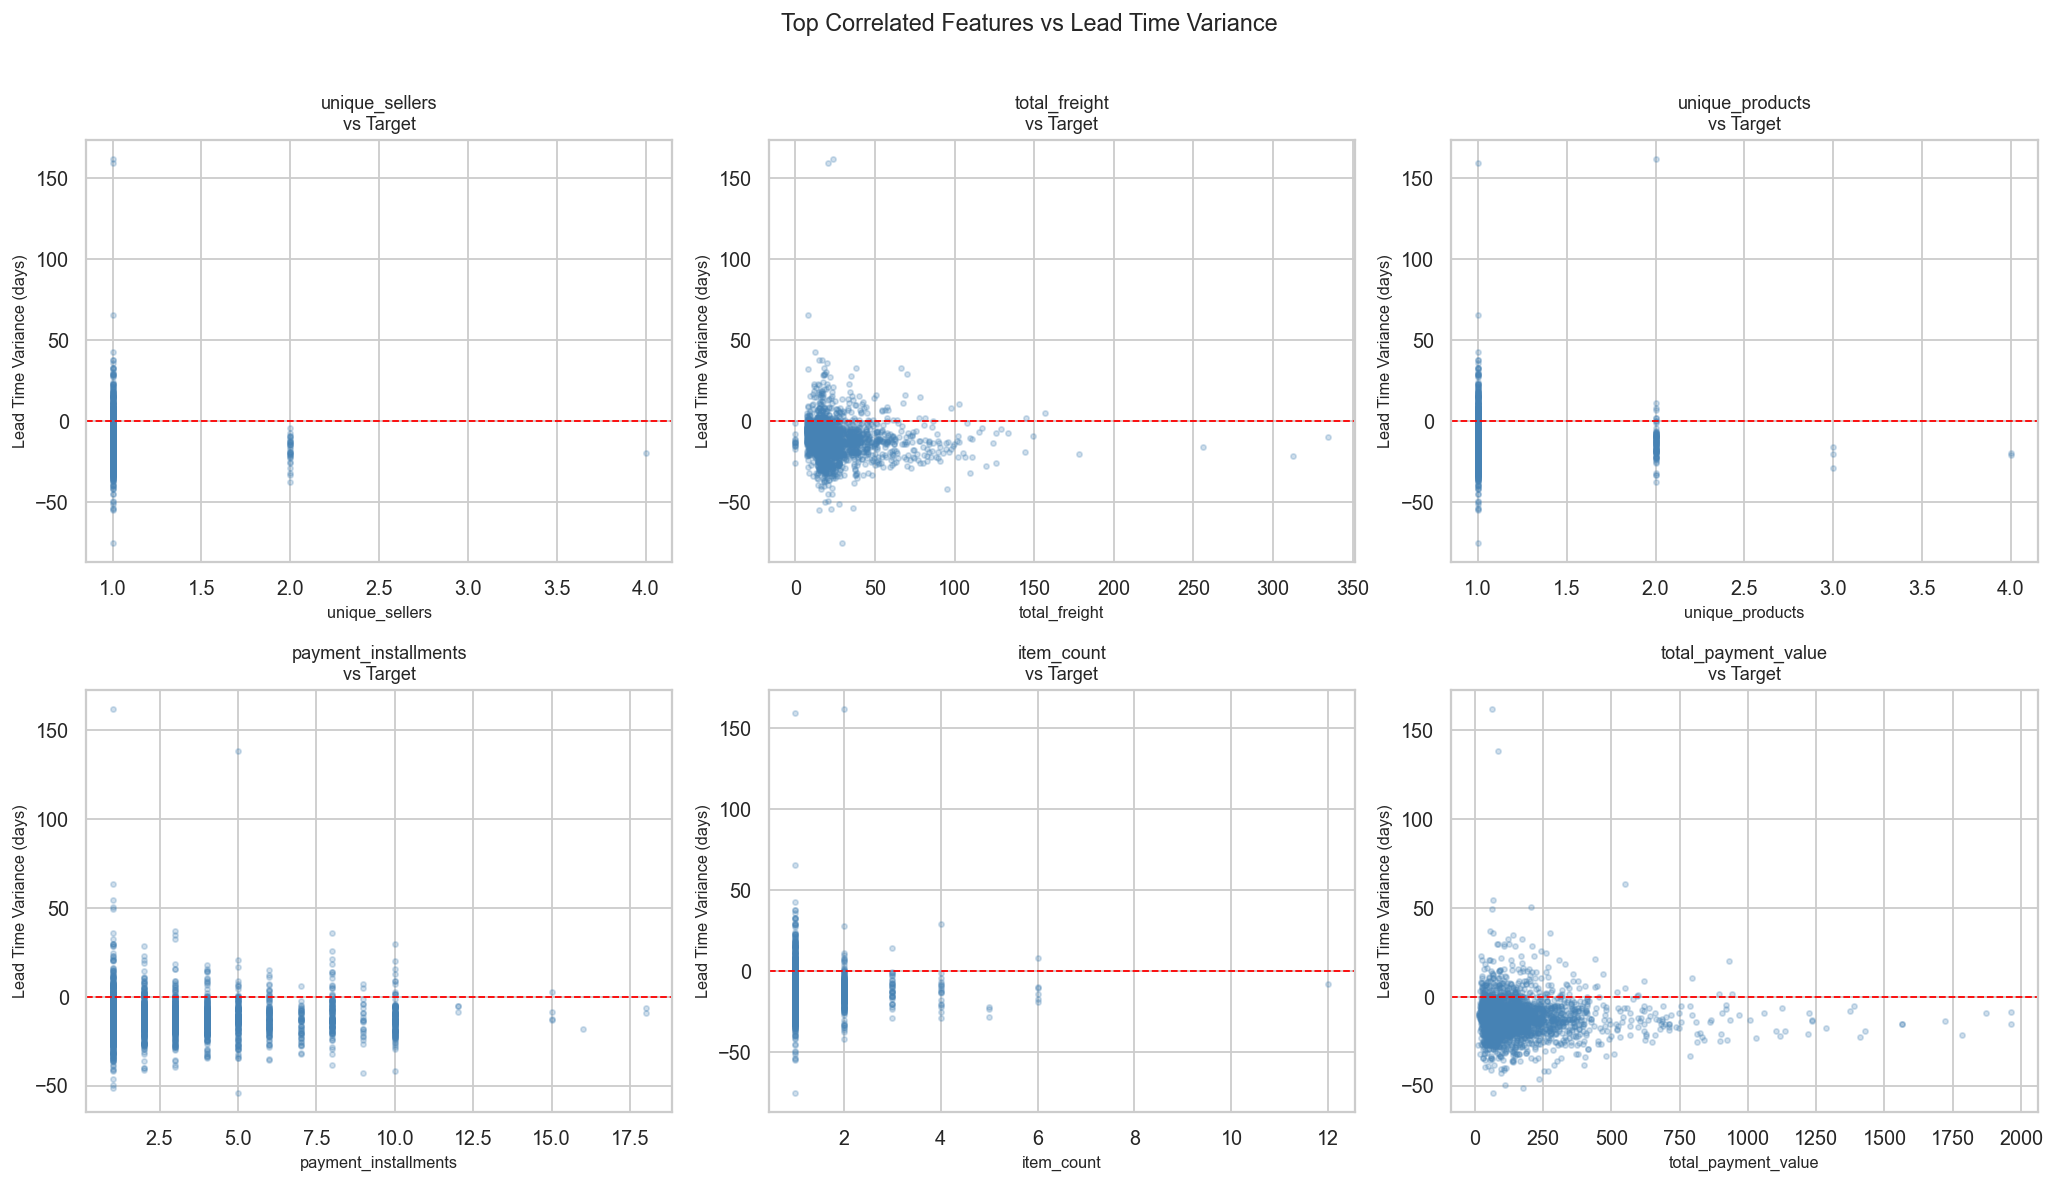

✓ Bivariate scatter plot saved


In [10]:
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sample = df_train[[feat, "lead_time_variance"]].dropna().sample(
        min(3000, len(df_train)), random_state=42
    )
    axes[i].scatter(sample[feat], sample["lead_time_variance"],
                    alpha=0.25, s=8, color="steelblue")
    axes[i].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel("Lead Time Variance (days)", fontsize=9)
    axes[i].set_title(f"{feat}\nvs Target", fontsize=10)

plt.suptitle("Top Correlated Features vs Lead Time Variance", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/eda_bivariate_scatter.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Bivariate scatter plot saved")

In [11]:
df_train["purchase_month"] = df_train["order_purchase_timestamp"].dt.to_period("M")
monthly = df_train.groupby("purchase_month").agg(
    order_count=("order_id", "count"),
    avg_variance=("lead_time_variance", "mean")
).reset_index()
monthly["purchase_month"] = monthly["purchase_month"].astype(str)

print("MONTHLY ORDER VOLUME & AVG LEAD TIME VARIANCE (train set)\n")
print(f"  {'Month':<12} {'Orders':>8}  {'Avg Variance (days)':>22}")
print("  " + "-" * 48)
for _, row in monthly.iterrows():
    print(f"  {row['purchase_month']:<12} {int(row['order_count']):>8}  {row['avg_variance']:>22.3f}")

MONTHLY ORDER VOLUME & AVG LEAD TIME VARIANCE (train set)

  Month          Orders     Avg Variance (days)
  ------------------------------------------------
  2016-09             1                  36.325
  2016-10           184                 -35.784
  2017-01           523                 -26.744
  2017-02          1144                 -18.518
  2017-03          1799                 -11.676
  2017-04          1638                 -12.559
  2017-05          2535                 -13.133
  2017-06          2198                 -12.002
  2017-07          2707                 -11.726
  2017-08          2919                 -12.297
  2017-09          2914                 -10.620
  2017-10          3118                 -11.083
  2017-11          5086                  -7.478
  2017-12          3865                 -12.316
  2018-01          4944                 -12.074
  2018-02          4630                  -7.396
  2018-03          4893                  -5.744
  2018-04          4756   

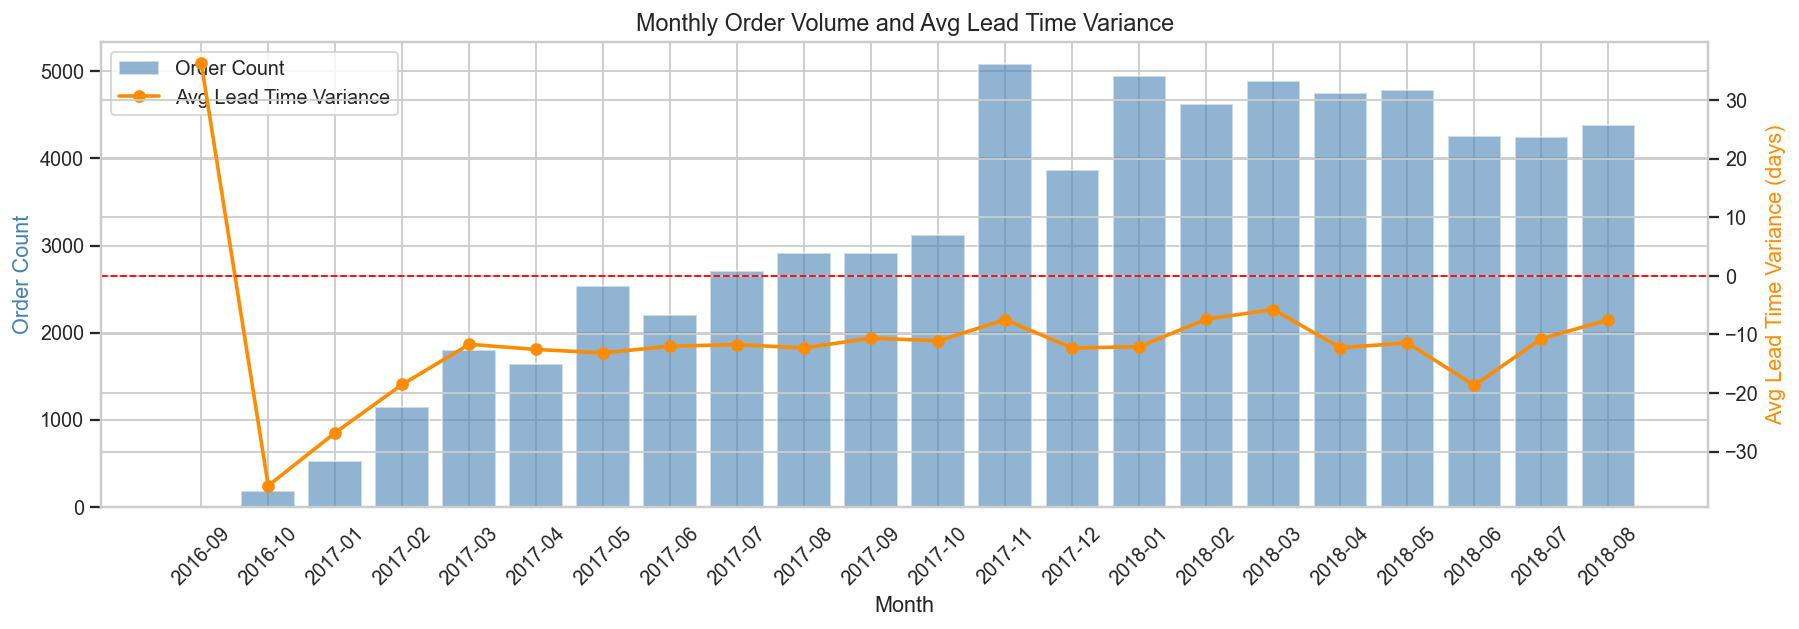

✓ Time series plot saved


In [12]:
fig, ax1 = plt.subplots(figsize=(14, 5))

color1 = "steelblue"
color2 = "darkorange"

ax1.bar(monthly["purchase_month"], monthly["order_count"],
        color=color1, alpha=0.6, label="Order Count")
ax1.set_xlabel("Month")
ax1.set_ylabel("Order Count", color=color1)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly["purchase_month"], monthly["avg_variance"],
         color=color2, marker="o", linewidth=2, label="Avg Lead Time Variance")
ax2.axhline(0, color="red", linestyle="--", linewidth=1)
ax2.set_ylabel("Avg Lead Time Variance (days)", color=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Monthly Order Volume and Avg Lead Time Variance", fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/eda_timeseries.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Time series plot saved")

In [13]:
state_stats = df_train.groupby("customer_state").agg(
    order_count=("order_id", "count"),
    avg_variance=("lead_time_variance", "mean"),
    pct_late=("lead_time_variance", lambda x: (x > 0).mean() * 100)
).reset_index().sort_values("avg_variance", ascending=False)

print("LEAD TIME VARIANCE BY CUSTOMER STATE (train set)\n")
print(f"  {'State':<8} {'Orders':>8} {'Avg Variance':>15} {'% Late':>10}")
print("  " + "-" * 46)
for _, row in state_stats.iterrows():
    print(f"  {row['customer_state']:<8} {int(row['order_count']):>8} "
          f"{row['avg_variance']:>15.3f} {row['pct_late']:>9.2f}%")

LEAD TIME VARIANCE BY CUSTOMER STATE (train set)

  State      Orders    Avg Variance     % Late
  ----------------------------------------------
  AL            286          -8.275     23.08%
  MA            501          -8.329     21.36%
  SE            229          -9.160     13.97%
  ES           1408          -9.763     11.93%
  BA           2332         -10.100     13.98%
  CE            883         -10.126     15.29%
  PI            353         -10.240     17.28%
  MS            487         -10.270     11.70%
  SP          28331         -10.397      5.86%
  SC           2471         -10.907      9.39%
  RJ           8628         -11.002     13.33%
  DF           1457         -11.331      6.59%
  GO           1374         -11.461      8.44%
  TO            192         -11.726      9.90%
  PB            362         -12.354     11.05%
  MG           7963         -12.551      5.80%
  PR           3415         -12.595      5.27%
  PE           1105         -12.652     11.40%
  RN    

In [14]:
seller_state_stats = df_train.groupby("seller_state").agg(
    order_count=("order_id", "count"),
    avg_variance=("lead_time_variance", "mean"),
    pct_late=("lead_time_variance", lambda x: (x > 0).mean() * 100)
).reset_index().sort_values("avg_variance", ascending=False)

print("LEAD TIME VARIANCE BY SELLER STATE (train set)\n")
print(f"  {'State':<8} {'Orders':>8} {'Avg Variance':>15} {'% Late':>10}")
print("  " + "-" * 46)
for _, row in seller_state_stats.iterrows():
    print(f"  {row['seller_state']:<8} {int(row['order_count']):>8} "
          f"{row['avg_variance']:>15.3f} {row['pct_late']:>9.2f}%")

LEAD TIME VARIANCE BY SELLER STATE (train set)

  State      Orders    Avg Variance     % Late
  ----------------------------------------------
  AM              3           9.347     66.67%
  SP          47848         -10.432      8.78%
  MA            281         -10.467     22.78%
  PA              4         -11.245      0.00%
  BA            366         -11.593      5.46%
  RJ           2935         -11.877      7.94%
  DF            550         -12.324      6.18%
  ES            226         -12.550      6.19%
  MG           5338         -12.650      5.49%
  RN             37         -12.987      8.11%
  SC           2525         -13.230      6.26%
  GO            302         -13.282      4.64%
  PR           5264         -13.284      6.84%
  CE             51         -13.900      7.84%
  PE            272         -14.899      5.15%
  MT            100         -15.081      4.00%
  RS           1352         -15.506      4.22%
  MS             32         -16.763      9.38%
  PI      

In [15]:
df_train["same_state"] = (
    df_train["customer_state"] == df_train["seller_state"]
).astype(int)

same_state_stats = df_train.groupby("same_state")["lead_time_variance"].agg(
    ["mean", "median", "std", "count",
     lambda x: (x > 0).mean() * 100]
).round(3)
same_state_stats.columns = ["mean", "median", "std", "count", "pct_late"]
same_state_stats.index = ["Cross-State", "Same-State"]

print("SAME STATE vs CROSS STATE DELIVERY (train set)\n")
print(same_state_stats.to_string())
print(f"\n  Cross-state orders : {(df_train['same_state']==0).sum():,}")
print(f"  Same-state orders  : {(df_train['same_state']==1).sum():,}")

SAME STATE vs CROSS STATE DELIVERY (train set)

               mean  median     std  count  pct_late
Cross-State -12.022 -13.126  11.195  43290     9.254
Same-State   -9.667  -9.435   7.849  24236     6.074

  Cross-state orders : 43,290
  Same-state orders  : 24,236


In [16]:
cat_stats = df_train.groupby("product_category_name_english").agg(
    order_count=("order_id", "count"),
    avg_variance=("lead_time_variance", "mean"),
    pct_late=("lead_time_variance", lambda x: (x > 0).mean() * 100)
).reset_index()

# Only show categories with >= 100 orders
cat_stats = cat_stats[cat_stats["order_count"] >= 100].sort_values(
    "avg_variance", ascending=False
)

print("CATEGORY-WISE LEAD TIME VARIANCE (categories with ≥100 orders, train set)\n")
print(f"  {'Category':<45} {'Orders':>8} {'Avg Variance':>15} {'% Late':>10}")
print("  " + "-" * 83)

print("\n  TOP 10 WORST (latest):")
for _, row in cat_stats.head(10).iterrows():
    print(f"  {str(row['product_category_name_english']):<45} "
          f"{int(row['order_count']):>8} "
          f"{row['avg_variance']:>15.3f} "
          f"{row['pct_late']:>9.2f}%")

print("\n  TOP 10 BEST (earliest):")
for _, row in cat_stats.tail(10).iterrows():
    print(f"  {str(row['product_category_name_english']):<45} "
          f"{int(row['order_count']):>8} "
          f"{row['avg_variance']:>15.3f} "
          f"{row['pct_late']:>9.2f}%")

CATEGORY-WISE LEAD TIME VARIANCE (categories with ≥100 orders, train set)

  Category                                        Orders    Avg Variance     % Late
  -----------------------------------------------------------------------------------

  TOP 10 WORST (latest):
  home_confort                                       263          -9.252      9.89%
  food                                               307          -9.281      9.45%
  audio                                              242          -9.325     13.64%
  construction_tools_construction                    504          -9.945     10.12%
  electronics                                       1728         -10.107      9.90%
  food_drink                                         168         -10.420      5.95%
  auto                                              2668         -10.433      8.32%
  computers                                          116         -10.472      7.76%
  home_construction                                  324 

In [17]:
pay_stats = df_train.groupby("primary_payment_type").agg(
    order_count=("order_id", "count"),
    avg_variance=("lead_time_variance", "mean"),
    pct_late=("lead_time_variance", lambda x: (x > 0).mean() * 100)
).reset_index().sort_values("avg_variance")

print("PAYMENT TYPE vs LEAD TIME VARIANCE (train set)\n")
print(f"  {'Payment Type':<20} {'Orders':>8} {'Avg Variance':>15} {'% Late':>10}")
print("  " + "-" * 58)
for _, row in pay_stats.iterrows():
    print(f"  {row['primary_payment_type']:<20} {int(row['order_count']):>8} "
          f"{row['avg_variance']:>15.3f} {row['pct_late']:>9.2f}%")

PAYMENT TYPE vs LEAD TIME VARIANCE (train set)

  Payment Type           Orders    Avg Variance     % Late
  ----------------------------------------------------------
  credit_card             51315         -11.391      7.94%
  debit_card               1010         -10.854      7.62%
  voucher                  1783         -10.782      8.02%
  boleto                  13417         -10.437      8.83%


In [18]:
item_stats = df_train.groupby("item_count").agg(
    order_count=("order_id", "count"),
    avg_variance=("lead_time_variance", "mean"),
    pct_late=("lead_time_variance", lambda x: (x > 0).mean() * 100)
).reset_index().sort_values("item_count")

print("ITEM COUNT vs LEAD TIME VARIANCE (train set)\n")
print(f"  {'Items':>6} {'Orders':>8} {'Avg Variance':>15} {'% Late':>10}")
print("  " + "-" * 44)
for _, row in item_stats.iterrows():
    print(f"  {int(row['item_count']):>6} {int(row['order_count']):>8} "
          f"{row['avg_variance']:>15.3f} {row['pct_late']:>9.2f}%")

ITEM COUNT vs LEAD TIME VARIANCE (train set)

   Items   Orders    Avg Variance     % Late
  --------------------------------------------
       1    60753         -11.054      8.29%
       2     5166         -12.206      6.60%
       3      922         -12.456      6.40%
       4      357         -12.167      5.60%
       5      138         -13.071      7.97%
       6      141         -13.270      8.51%
       7       19         -14.614      0.00%
       8        6         -11.255      0.00%
       9        3         -15.560      0.00%
      10        6         -12.814      0.00%
      11        3         -10.049      0.00%
      12        5          -9.211      0.00%
      13        1          -2.259      0.00%
      14        2          -7.878      0.00%
      15        1          -5.153      0.00%
      20        2         -10.425      0.00%
      21        1           3.752    100.00%


In [19]:
print("OUTLIER DETECTION — IQR METHOD (train set)\n")

outlier_summary = []
for col in num_cols:
    if col not in df_train.columns:
        continue
    s = df_train[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((s < lower) | (s > upper)).sum()
    pct_out = n_out / len(s) * 100
    outlier_summary.append({
        "column": col,
        "Q1": round(Q1, 2), "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "n_outliers": n_out,
        "pct_outliers": round(pct_out, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)

print(f"  {'Column':<35} {'Lower':>10} {'Upper':>10} {'N Outliers':>12} {'% Out':>8}")
print("  " + "-" * 80)
for _, row in outlier_df.iterrows():
    print(f"  {row['column']:<35} {row['lower_bound']:>10.2f} "
          f"{row['upper_bound']:>10.2f} {int(row['n_outliers']):>12,} "
          f"{row['pct_outliers']:>7.2f}%")

# Also check target variable outliers
tgt = df_train["lead_time_variance"]
Q1t, Q3t = tgt.quantile(0.25), tgt.quantile(0.75)
IQRt = Q3t - Q1t
n_out_tgt = ((tgt < Q1t - 1.5*IQRt) | (tgt > Q3t + 1.5*IQRt)).sum()
print(f"\n  TARGET (lead_time_variance):")
print(f"    IQR bounds  : [{Q1t - 1.5*IQRt:.2f}, {Q3t + 1.5*IQRt:.2f}]")
print(f"    N outliers  : {n_out_tgt:,}  ({n_out_tgt/len(tgt)*100:.2f}%)")

OUTLIER DETECTION — IQR METHOD (train set)

  Column                                   Lower      Upper   N Outliers    % Out
  --------------------------------------------------------------------------------
  product_weight_g                      -1950.00    4050.00        9,571   14.18%
  total_freight                            -1.40      39.32        6,813   10.09%
  item_count                                1.00       1.00        6,773   10.03%
  total_price                            -110.10     305.90        5,363    7.94%
  total_payment_value                    -110.33     349.19        5,293    7.84%
  avg_price                              -105.10     286.90        5,145    7.62%
  product_height_cm                       -10.00      38.00        4,538    6.72%
  payment_installments                     -3.50       8.50        4,254    6.30%
  product_description_lenght             -617.50    1962.50        4,089    6.14%
  unique_products                           1.00     

In [20]:
install_stats = df_train.groupby("payment_installments").agg(
    order_count=("order_id", "count"),
    avg_variance=("lead_time_variance", "mean"),
    pct_late=("lead_time_variance", lambda x: (x > 0).mean() * 100)
).reset_index().sort_values("payment_installments")

# Only show installment values with >= 50 orders
install_stats = install_stats[install_stats["order_count"] >= 50]

print("PAYMENT INSTALLMENTS vs LEAD TIME VARIANCE (train set)\n")
print(f"  {'Installments':>13} {'Orders':>8} {'Avg Variance':>15} {'% Late':>10}")
print("  " + "-" * 52)
for _, row in install_stats.iterrows():
    print(f"  {int(row['payment_installments']):>13} {int(row['order_count']):>8} "
          f"{row['avg_variance']:>15.3f} {row['pct_late']:>9.2f}%")

PAYMENT INSTALLMENTS vs LEAD TIME VARIANCE (train set)

   Installments   Orders    Avg Variance     % Late
  ----------------------------------------------------
              1    32647         -10.836      7.91%
              2     8491         -11.181      8.26%
              3     7130         -11.504      8.06%
              4     4808         -11.578      7.95%
              5     3564         -11.587      8.36%
              6     2664         -11.585      8.67%
              7     1073         -11.589      8.11%
              8     2892         -11.701      9.13%
              9      433         -11.444      8.78%
             10     3573         -11.810      8.20%
             12       99         -11.757     11.11%
             15       55         -10.937      9.09%


In [21]:
summary = """
EDA SUMMARY — KEY FINDINGS (train set only)
═══════════════════════════════════════════════════════════════

  TARGET:
  • Mean variance = -11.18 days → Olist systematically over-estimates
    delivery by ~11 days as a buffer
  • Only 8.11% of orders are late — heavy class imbalance in target
  • Extreme outliers exist on both ends (>100d late, <-100d early)
  • Distribution is left-skewed — will likely need log/robust scaling

  FEATURES TO ENGINEER (confirmed from EDA):
  • Estimated delivery window (estimated_date - purchase_date) — 
    likely very strong predictor
  • Same-state vs cross-state flag — geospatial signal confirmed
  • Purchase month/day-of-week — time series shows seasonality
  • Seller-level avg historical variance — seller quality signal
  • Product volumetric weight (L x H x W / 5000) — logistics proxy
  • Freight-to-price ratio — shipping complexity proxy

  CLEANING PRIORITIES (confirmed from EDA):
  • Cap extreme outliers in target (> ±100 days) — investigate first
  • Handle ~1.4% null product categories
  • Handle ~0.67% null review fields (will be excluded as features)
  • Handle 2 null product dimension rows

  WATCH OUT FOR:
  • review_score — NOT to be used as feature (post-delivery leakage)
  • customer_city / seller_city — too high cardinality, use state only
  • Geolocation table not merged yet — will use in feature engineering
    for distance proxy calculation

═══════════════════════════════════════════════════════════════
"""
print(summary)


EDA SUMMARY — KEY FINDINGS (train set only)
═══════════════════════════════════════════════════════════════

  TARGET:
  • Mean variance = -11.18 days → Olist systematically over-estimates
    delivery by ~11 days as a buffer
  • Only 8.11% of orders are late — heavy class imbalance in target
  • Extreme outliers exist on both ends (>100d late, <-100d early)
  • Distribution is left-skewed — will likely need log/robust scaling

  FEATURES TO ENGINEER (confirmed from EDA):
  • Estimated delivery window (estimated_date - purchase_date) — 
    likely very strong predictor
  • Same-state vs cross-state flag — geospatial signal confirmed
  • Purchase month/day-of-week — time series shows seasonality
  • Seller-level avg historical variance — seller quality signal
  • Product volumetric weight (L x H x W / 5000) — logistics proxy
  • Freight-to-price ratio — shipping complexity proxy

  CLEANING PRIORITIES (confirmed from EDA):
  • Cap extreme outliers in target (> ±100 days) — investigate 